## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Fall 2023)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1 (30 points)**: The SIR epidemimodel is one of the simplest compartmental models, and many models are derivatives of this basic form(https://en.wikipedia.org/wiki/Compartmental_models_in_epidemiology). The model consists of three compartments: 
The number of susceptible individuals (S), the number of infectious individuals (I), and the number of of removed (and immune) or deceased individuals (R). When we account for the vaccination impacts to the model, we have the following SIRVI model:
$$ \frac{dS}{dt} = -\beta SI -\mu S, $$
$$ \frac{dI}{dt} = \beta SI +\alpha VI -\gamma I, $$
$$ \frac{dV}{dt} = \mu S -\alpha VI, $$
$$ \frac{dR}{dt} = \gamma I ,$$

where $V$ is the number of vaccinated individuals, the parameters $\beta$ represents the infectious rate of susceptibles, $\gamma$ is the recovery rate, $\mu$ is the vaccine rate of susceptibles, and $\alpha$ is the infectious rate of vaccinated. We assume will use day as our unit of time, $t$. This means that, for example,$t=2$ would be 2 days.

Solve this SIRVI system using `solve_ivp`. Assuming the parameters $\alpha =0.3, \beta =0.02, \gamma = 0.6$, and $\mu = 0.3$ with the following initial conditions:

* $S(0) = 150$
* $I(0) = 20$
* $V(0) = 50$
* $R(0) = 0$
Evolve the model for 5 days using a timestep of $\Delta t = 0.01$ days.

**Code you need to write to solve this problem**:
1. A function that takes in a set of time values as well as the current values for $S$, $I$, $V$, $R$ and **returns** the derivatives for each variable, $\frac{dS}{dt}$, $\frac{dI}{dt}$, $\frac{dV}{dt}$,and $\frac{dR}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.(**6pts**)
2. A set of variables for storing your initial conditions, $S_0$, $I_0$, $V_0$, and $R_0$, set to the correct initial values.(**6pts**)
3. A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.(**6pts**)
4. Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. (**6pts**)
5. Code that unpacks the solution so that you can plot it.(**6pts**)

**Note**: you will not need the "`args`" argument for `solve_ivp` for this case because any model parameters that might be needed for this system are provided directly as numbers in the set of  ODEs include above.

**1**. Define a function that takes in a set of time values as well as the current values for $S$, $I$, $V$, $R$ and **returns** the derivatives for each variable, $\frac{dS}{dt}$, $\frac{dI}{dt}$, $\frac{dV}{dt}$,and $\frac{dR}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.(**6pts**)

In [26]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here defining the derivs function

In [27]:
### ANSWER ###
def derivs(t, vals):
    s, i, v, r = vals
    dsdt = -0.02*s*i - 0.3*s
    didt = 0.02*s*i + 0.3*v*i - 0.6*i
    dvdt = 0.3*s -0.3*v*i
    drdt = 0.6*i
    return dsdt, didt, dvdt, drdt

**2**. Store a list of variables for your initial conditions, $S_0$, $I_0$, $V_0$, and $R_0$, set to the correct initial values.(**6pts**)

In [ ]:
# Put your code here creating a list of initial values


In [28]:
### ANSWER ###
s0 = 150
i0 = 20
v0 = 50
r0 = 0
ICs = [s0, i0, v0,r0]

**3**. Creat a variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above. Remember: the start value of `np.arange` is inclusive but goes up to but does not include the end value.(**6pts**)

In [ ]:
# Put your code here generating the time series to solve for


In [33]:
### ANSWER ###
t = np.arange(0, 5, 0.01)

**4**. Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. (**6pts**)

In [ ]:
# Put your code here using solve_ivp

In [34]:
### ANSWER ###
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t)

**5**. Code that unpacks the solution so that you can plot it.(**6pts**)

In [ ]:
# Put your code here that stores solutions for S, I, V,and R as separate variables


In [35]:
### ANSWER ###
s = sol.y[0,:]
i = sol.y[1,:]
v = sol.y[2,:]
r = sol.y[3,:]

&#9989;&nbsp; **Question 2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of all four variables, susceptible, infected , vaccinated, and removed individual number as a function time. Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

The points for this question are distributed as follows:
- **1.5pts**: susceptible individual number $S$
- **1.5pts**: infected individual number $I$
- **1.5pts**: vaccinated didividual number $V$
- **1.5pts**: removed didividual number $R$
- **1pt**: x axis label `Time in days`
- **1pt**: y axis label `Radiolabeled carbon`
- **1pt**: title `Accumulated carbon over time`
- **1pt**: legend, with labels `Birch`, `Mycorrhizae`, and `Fir`

If all goes well, you should end up with something that looks like this:

<img src="Quiz4_005.png" alt="Quiz4_005" border="0" width=500>

In [3]:
# put your code here

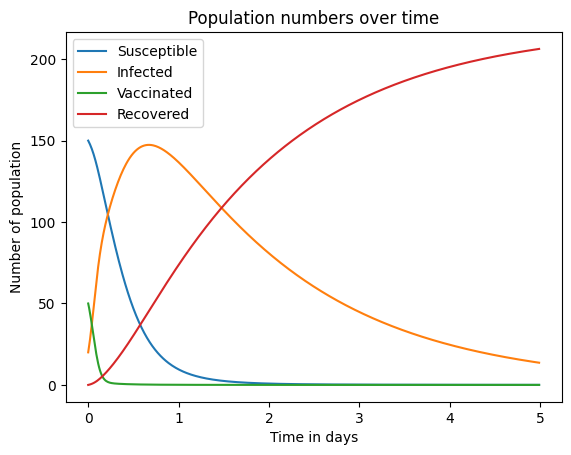

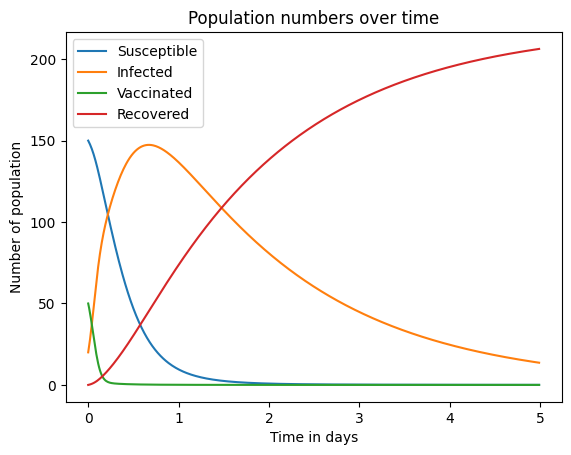

In [36]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

# In days
plt.figure(1)
plt.plot(t,s,label="Susceptible")
plt.plot(t,i,label="Infected")
plt.plot(t,v,label="Vaccinated")
plt.plot(t,r,label="Recovered")
plt.xlabel("Time in days")
plt.ylabel("Number of population")
plt.title("Population numbers over time")
plt.legend()

# In days
plt.figure(2)
plt.plot(t,s,label="Susceptible")
plt.plot(t,i,label="Infected")
plt.plot(t,v,label="Vaccinated")
plt.plot(t,r,label="Recovered")
plt.xlabel("Time in days")
plt.ylabel("Number of population")
plt.title("Population numbers over time")
plt.legend()
plt.savefig("Quiz4_005.png")


## Part 2: Data Visualization (50 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 30 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. 

&#9989;&nbsp; **Question 2 (20 points total)**: Grade the visualization using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (4 Points)** 
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

**<font size=+3>&#9998;</font> For your first choice visualization:**

**1) Which visualization did you choose?**  
*Put your answer here*  

**2) What story is it trying to convey?**  
*Put your answer here*  

**3) Using the rubric, how many points (out of 8) do you give it?**  
*Put your answer here*  

**<font size=+3>&#9998;</font> For your second choice visualization:**

**1) Which visualization did you choose?**  
*Put your answer here*  

**2) What story is it trying to convey?**  
*Put your answer here*  

**3) Using the rubric, how many points (out of 8) do you give it?**  
*Put your answer here*  

**<font size=+3>&#9998;</font> For your third choice visualization:**

**1) Which visualization did you choose?**  
*Put your answer here*  

**2) What story is it trying to convey?**  
*Put your answer here*  

**3) Using the rubric, how many points (out of 8) do you give it?**  
*Put your answer here*  

### Visualizations to Choose From


**Visualization 1**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Picture2.jpg?raw=true">

**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true">

**Visualization 3**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/badGraphic.png?raw=true">

**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (7).png?raw=true">

**Visualization 5**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (2).png?raw=true">

**Visualization 6**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true">

**Visualization 7**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (9).png?raw=true">

**Visualization 8**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/whimsical_squid.png?raw=true">

### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations!



**QUESTION 1 RESPONSES HERE**

**QUESTION 2 RESPONSES HERE**